In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from experiments.comparison import ComparisonConfig, load_datasets
from experiments.plots import learning_curves, equation_curves, forcing_curves, physics_curves, field_slices
from experiments.vorticity_plots import representation_summary, representation_rollouts, vorticity_constraints

torch.set_num_threads(1)
# AVF residual checks require full float32, including CUDA convolutions.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
if not torch.cuda.is_available():
    raise RuntimeError("Select a Python kernel with CUDA-enabled PyTorch and GPU access")
device = "cuda"
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

In [2]:
# Use the current velocity notebook output so both representations share one recorded protocol.
datasets = load_datasets(root / "datasets" / "large")
velocity_results = torch.load(
    root / "results" / "local_smoke_test_seeds_8_18_28" / "results.pt",
    map_location="cpu", weights_only=True,
)
# Audit fix: require recorded loss, integration, and update settings before reusing a reference.
config = ComparisonConfig.from_record({**velocity_results["config"], "device": device})
output = root / "results" / "phfno_fno_vorticity_avf"

In [3]:
# Reuse only a complete AVF comparison with matching data and protocol.
from importlib import reload
import json
from experiments import vorticity_comparison
from experiments.comparison import summarize_run, same_protocol

reload(vorticity_comparison)
result_path = output / "results.pt"
if result_path.is_file():
    vorticity_results = torch.load(result_path, map_location="cpu", weights_only=True)
    vorticity_comparison.validate_velocity_reference(velocity_results, datasets, config)
    vorticity_comparison.validate_velocity_reference(vorticity_results, datasets, config)
    if vorticity_results.get("state_representation") != "vorticity":
        raise ValueError("Expected vorticity-trained AVF results")
    for run in vorticity_results["runs"]:
        checkpoint_path = output / f"{run['model']}_{run['seed']}.pt"
        checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
        if ((checkpoint["model"], checkpoint["seed"]) != (run["model"], run["seed"])
                or checkpoint.get("state_representation") != "vorticity"
                or checkpoint["best_step"] != run["best_step"]
                or not same_protocol(checkpoint["config"], vorticity_results["config"])):
            raise ValueError(f"Checkpoint does not match the saved AVF run: {checkpoint_path}")
    reference = {**velocity_results, "runs": [summarize_run(run) for run in velocity_results["runs"]]}
    (output / "velocity_reference.json").write_text(json.dumps(reference, indent=2, allow_nan=False) + "\n")
else:
    vorticity_results = vorticity_comparison.run_vorticity_comparison(
        datasets, config, output, velocity_reference=velocity_results,
    )

In [4]:
failure_records = [
    {"model": run["model"], "seed": run["seed"], "family": family, **failure}
    for run in vorticity_results["runs"]
    for family, metrics in run["test"].items()
    for failure in metrics.get("failures", [])
]
failure_records or "All held-out AVF rollouts completed."

[{'model': 'PHFNO',
  'seed': 8,
  'family': 'random',
  'trajectory_index': 3,
  'step': 15,
  'time': 0.375,
  'reason': 'AVF step did not converge: nonfinite state or residual',
  'source_trajectory_index': 31},
 {'model': 'PHFNO',
  'seed': 18,
  'family': 'random',
  'trajectory_index': 3,
  'step': 1,
  'time': 0.02500000037252903,
  'reason': 'AVF step did not converge after 100 iterations (residual 3.170e+00)',
  'source_trajectory_index': 31}]

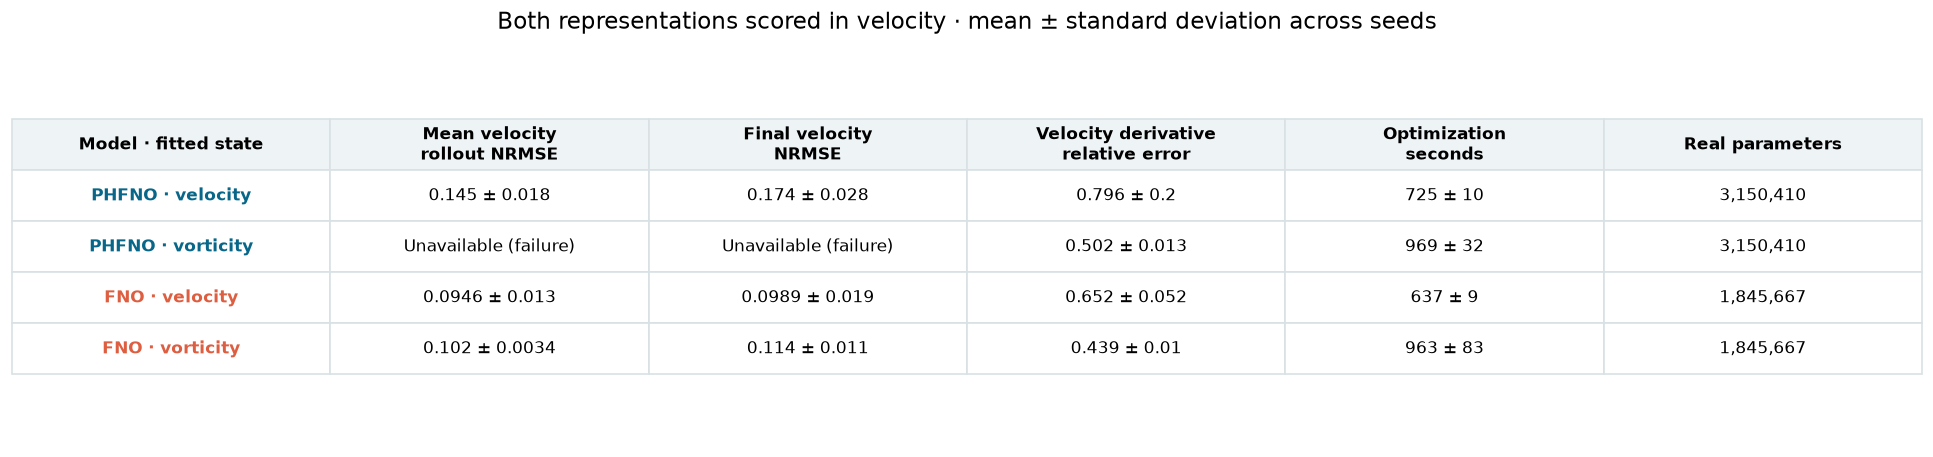

In [5]:
figure = representation_summary(velocity_results, vorticity_results)
plt.show()

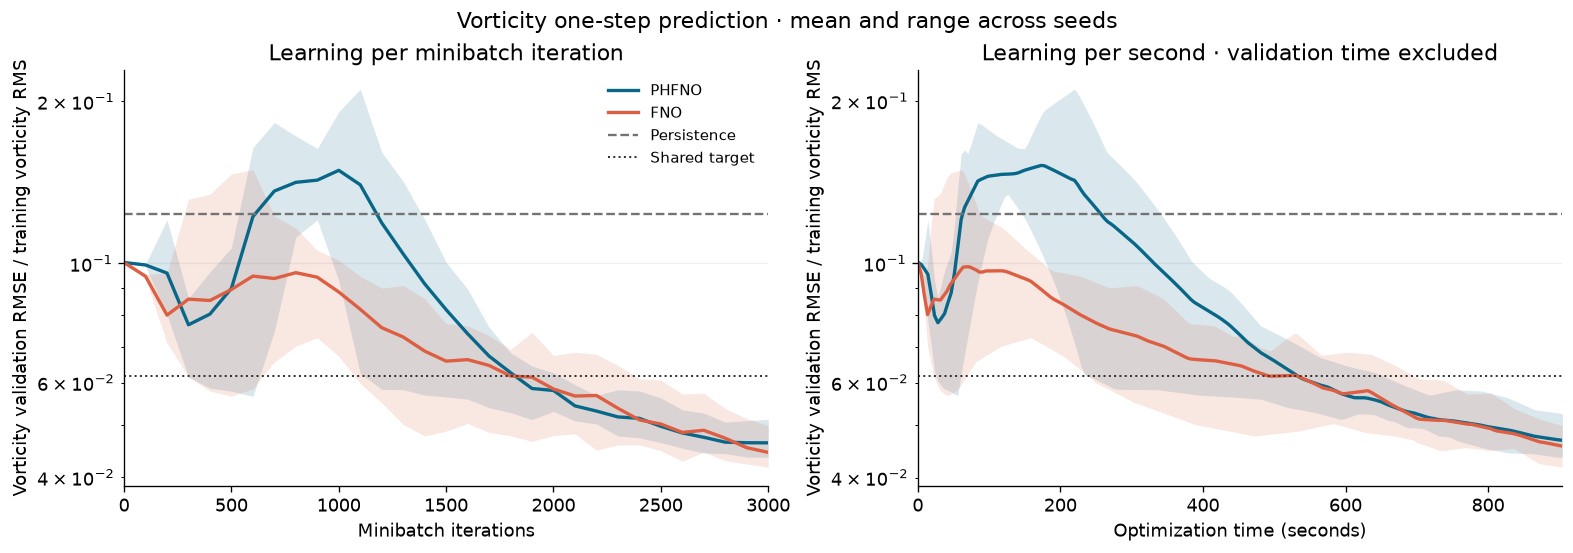

In [6]:
figure = learning_curves(vorticity_results)
figure.suptitle("Vorticity one-step prediction · mean and range across seeds")
for axis in figure.axes:
    axis.set_ylabel("Vorticity validation RMSE / training vorticity RMS")
plt.show()

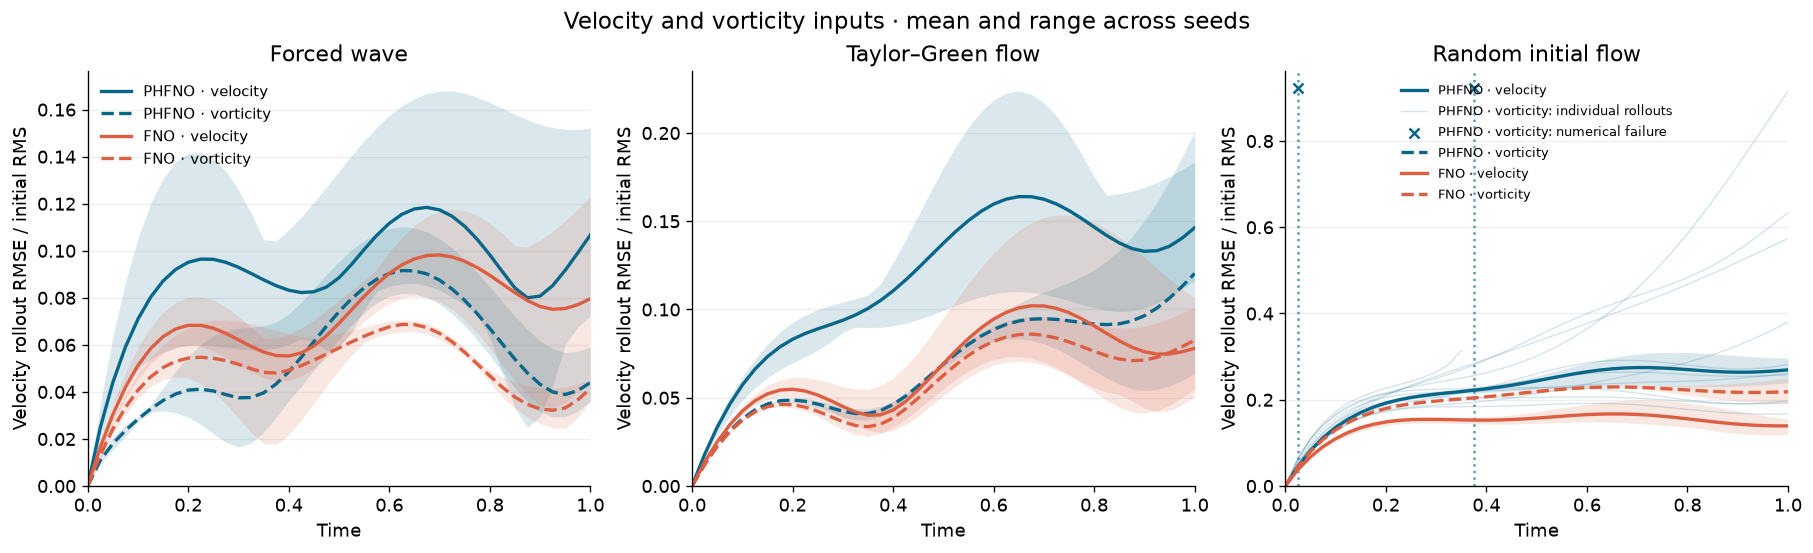

In [7]:
figure = representation_rollouts(velocity_results, vorticity_results)
plt.show()

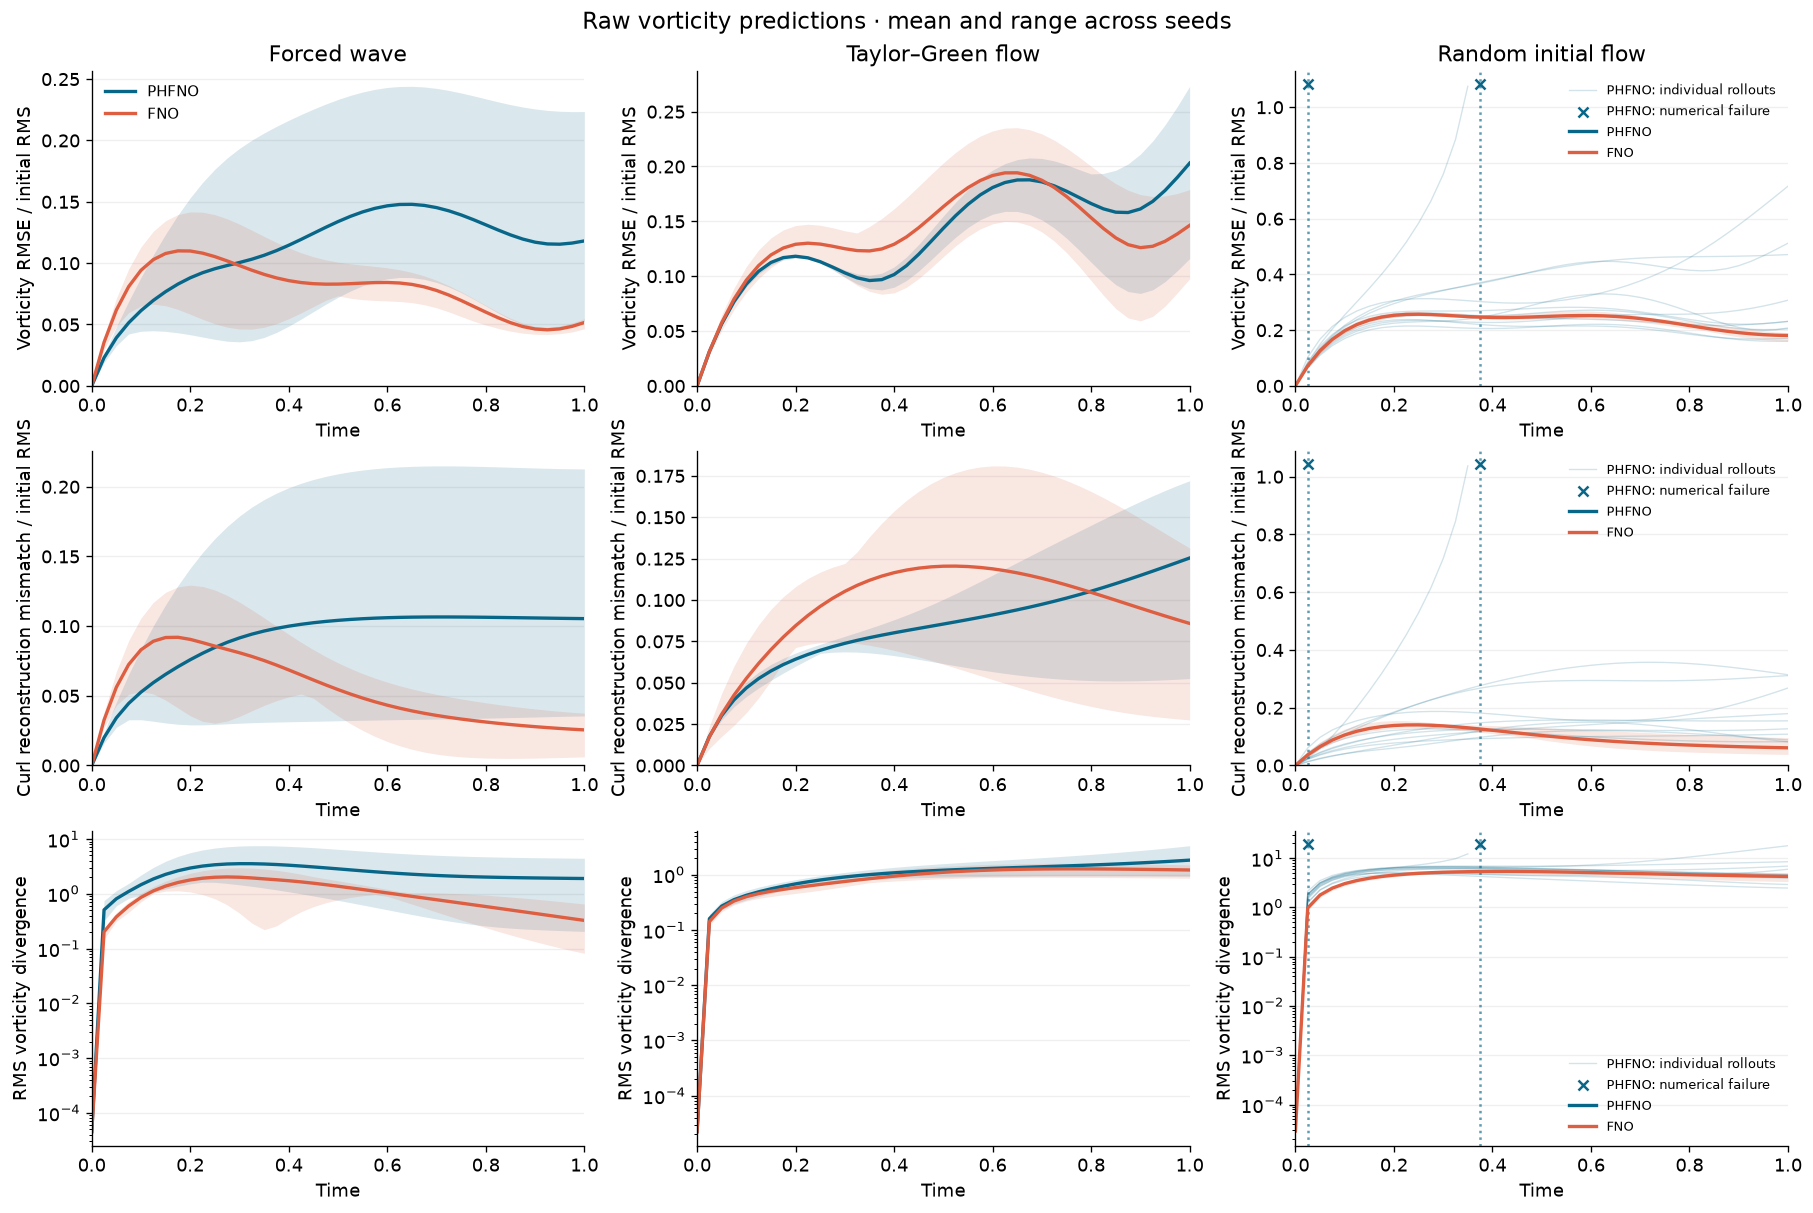

In [8]:
figure = vorticity_constraints(vorticity_results)
plt.show()

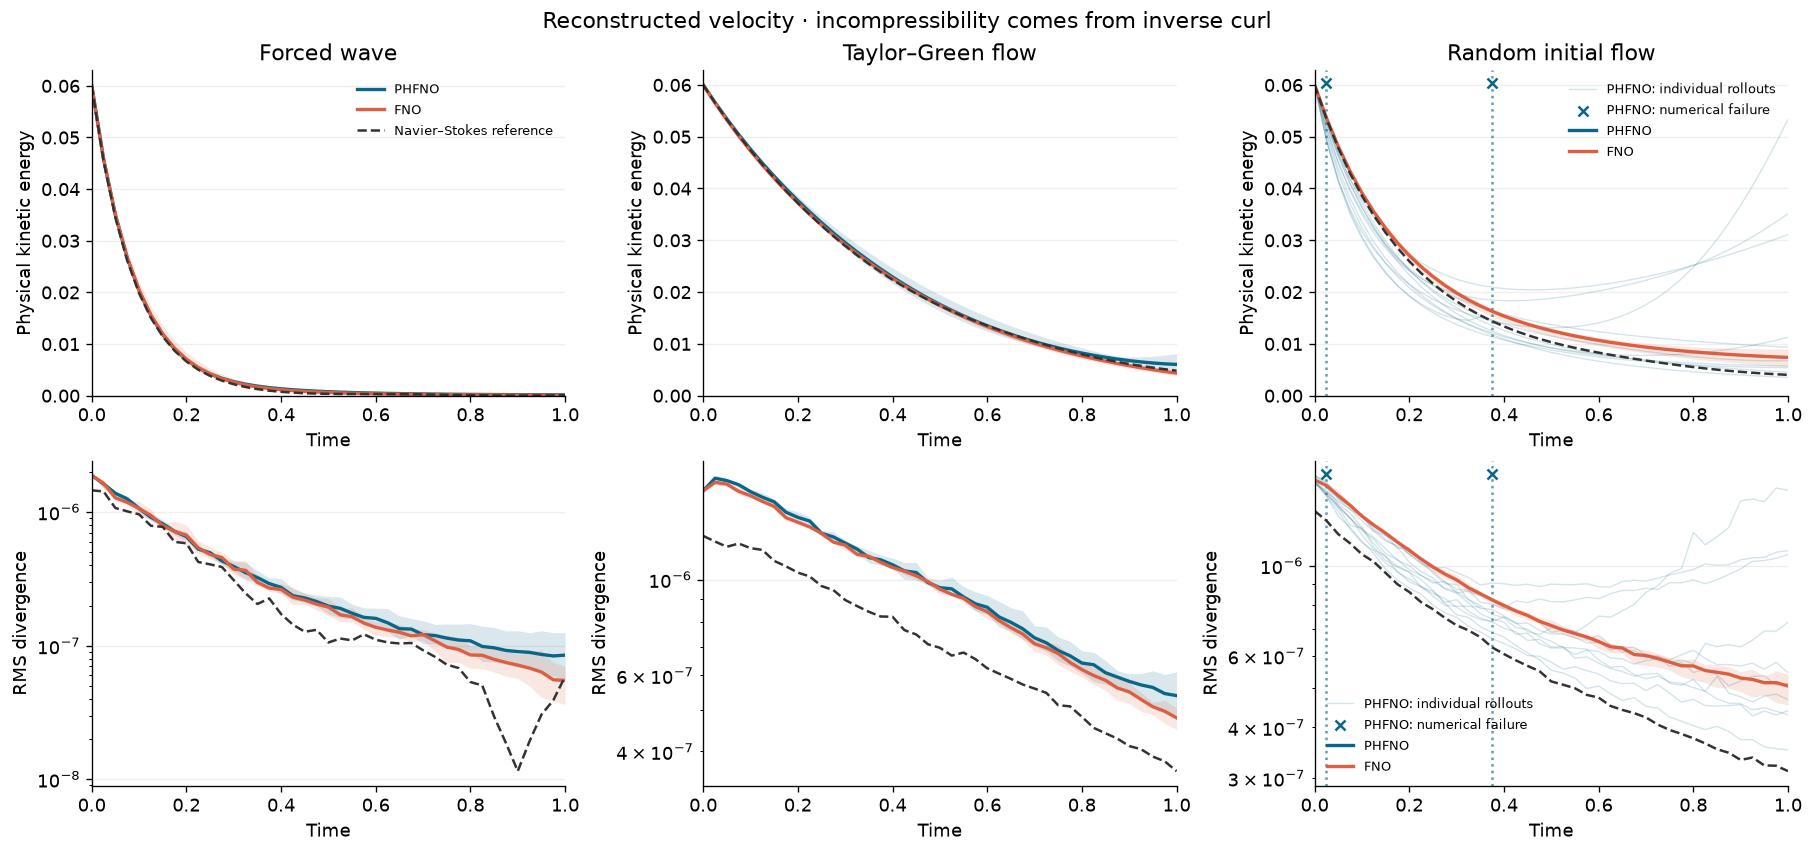

In [9]:
figure = physics_curves(vorticity_results)
figure.suptitle("Reconstructed velocity · incompressibility comes from inverse curl")
plt.show()

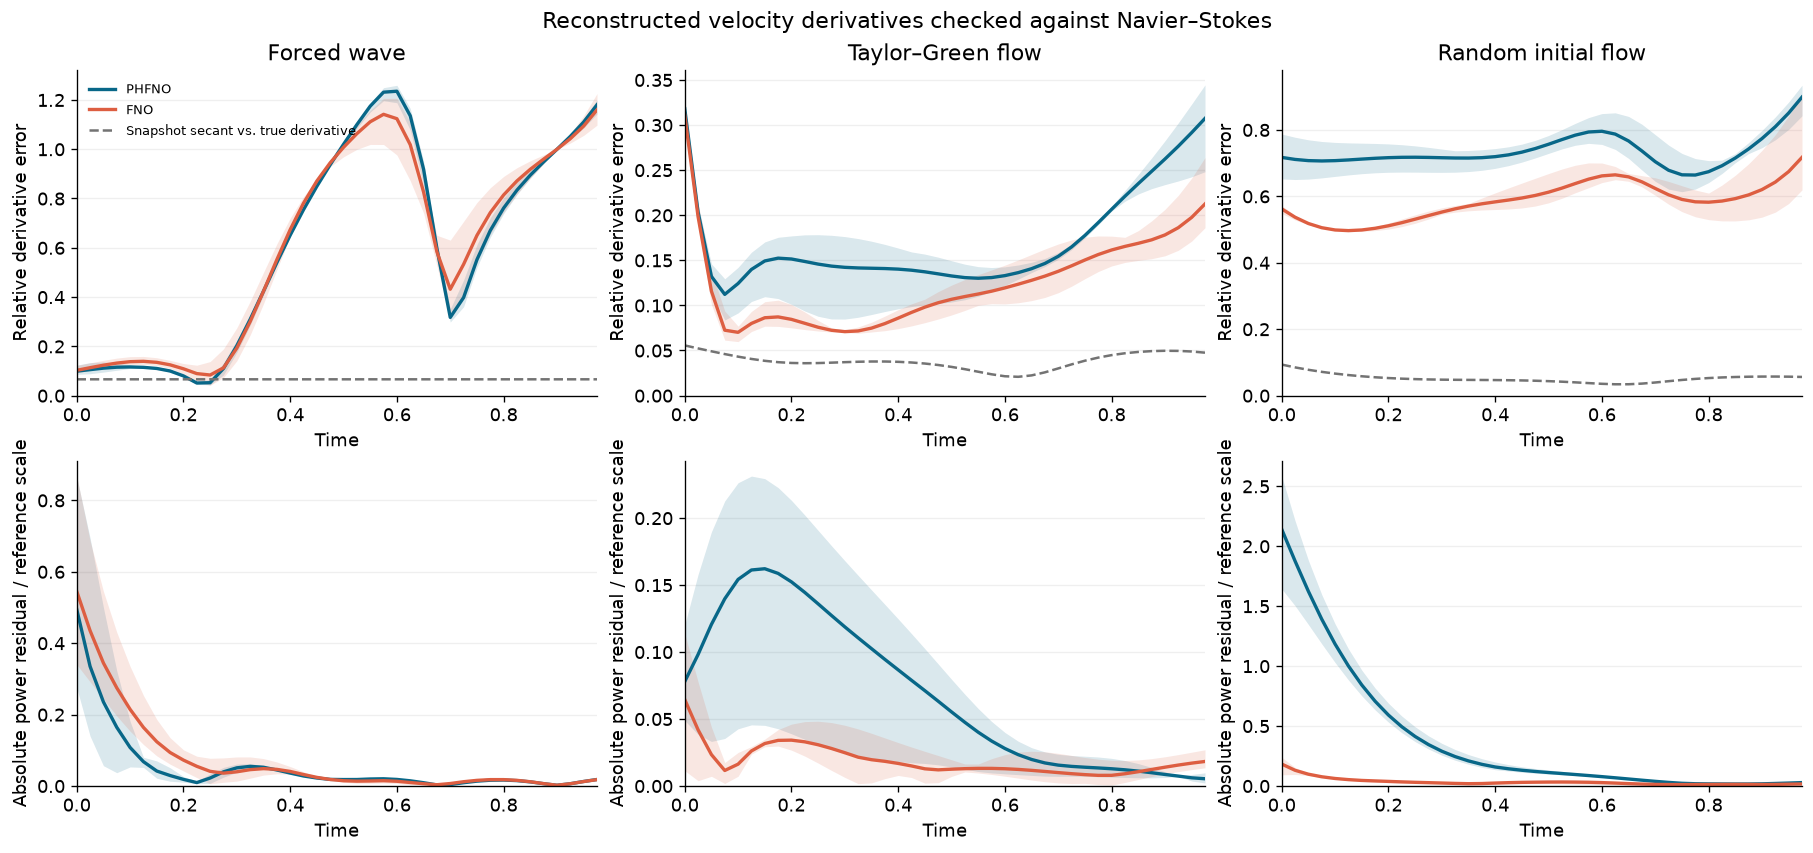

In [10]:
figure = equation_curves(vorticity_results)
figure.suptitle("Reconstructed velocity derivatives checked against Navier–Stokes")
plt.show()

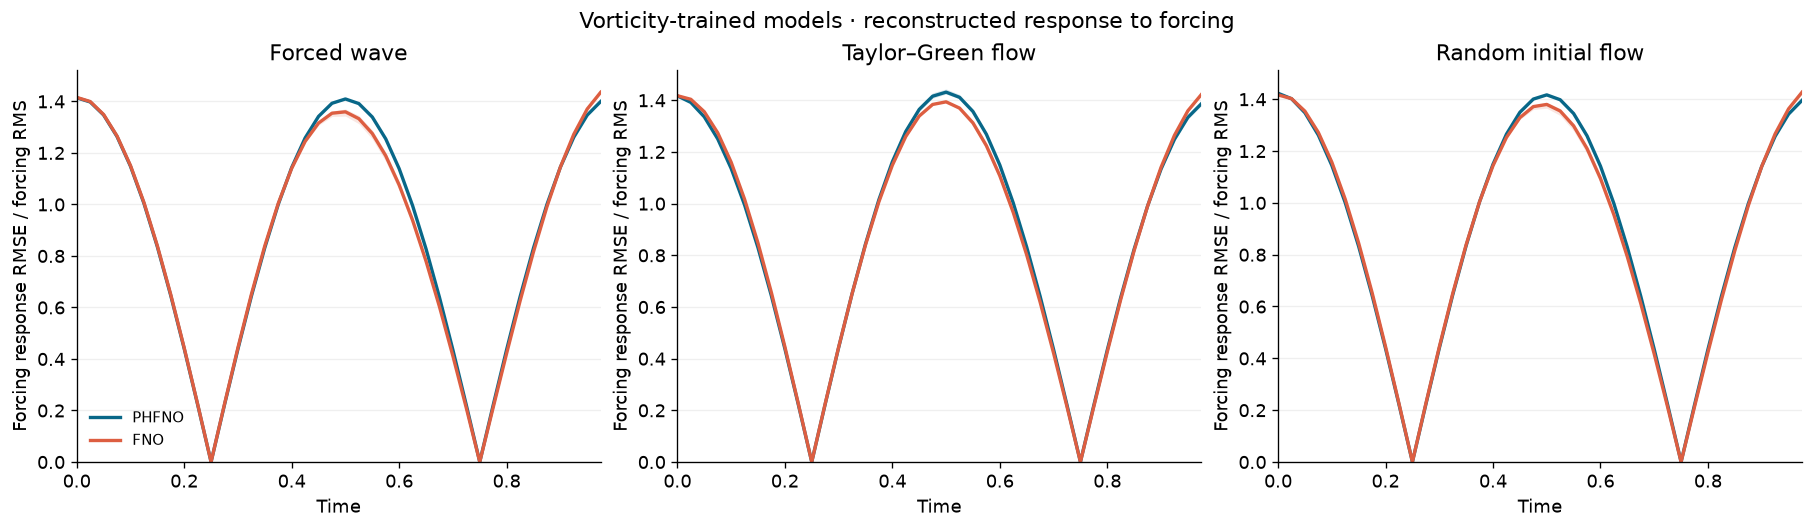

In [11]:
figure = forcing_curves(vorticity_results)
figure.suptitle("Vorticity-trained models · reconstructed response to forcing")
plt.show()

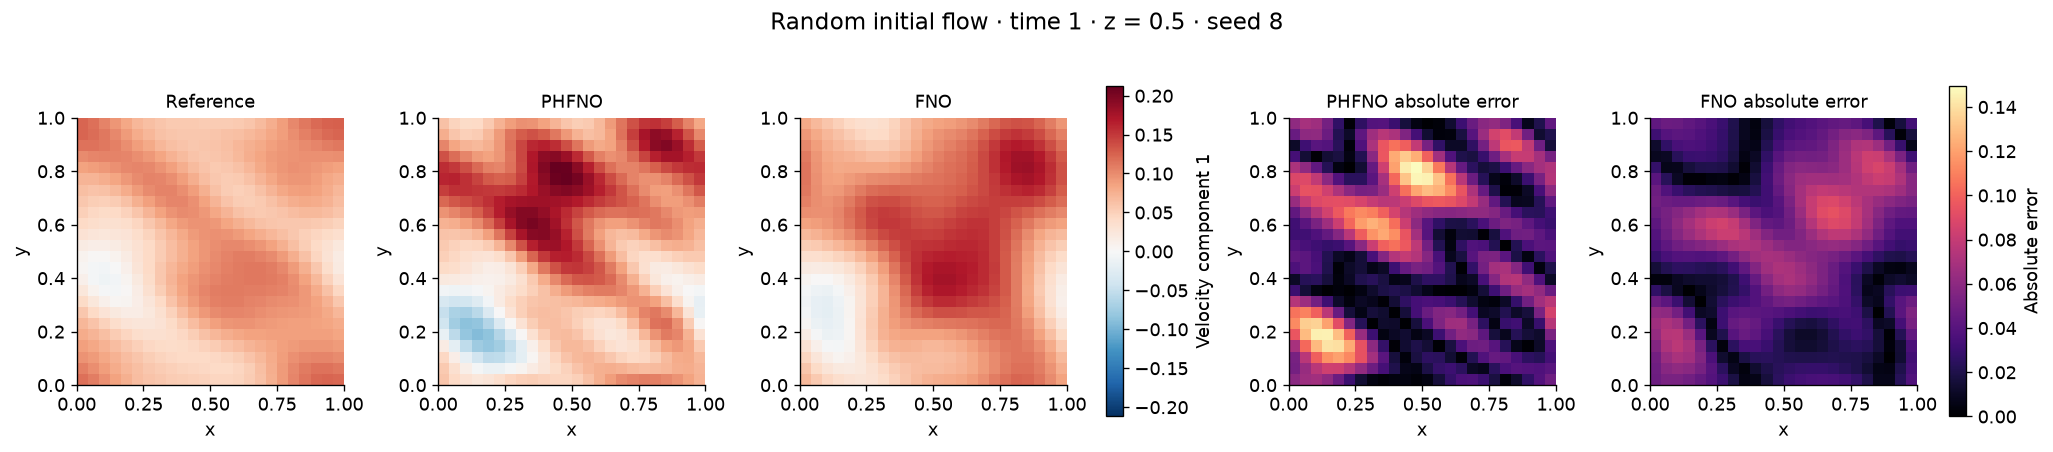

In [12]:
figure = field_slices(vorticity_results, family="random", seed=config.seeds[0])
plt.show()